## Modelo Fuzzy-AHP (F-AHP) & Simulação de Incerteza de Monte Carlo
### Avaliação Hierárquica Multicritério para Armazenamento de CO₂ em Cavernas de Sal

Este notebook implementa o pipeline analítico completo do método **Fuzzy Analytic Hierarchy Process (F-AHP)** integrado à modelagem estocástica de incerteza por **Simulação de Monte Carlo** e **SMAA (Stochastic Multicriteria Acceptability Analysis)**.

#### Estrutura Modular da Pesquisa:
1. **Macrocritérios Principais** (Nível 1 da hierarquia: Critérios $A$ a $F$).
2. **Grupos de Subcritérios** (Nível 2 da hierarquia: Subcritérios de $A$, $B$, $C$, $D$, $E$ e $F$).

> **Operação Flexível:** O arquivo `.csv` é informado apenas uma vez na inicialização. O catálogo dinâmico detecta todos os macrocritérios e famílias de subcritérios e atribui códigos a eles. Na célula de configurações, você escolhe qual grupo analisar (ex.: `GLOBAL`, `A`, `B`, etc.) e todo o notebook é executado sobre o grupo selecionado.


## Configuração de Ambiente e Importação de Bibliotecas
Inicialização dos módulos científicos (`numpy`, `pandas`, `scipy.stats`, `mcerp`), motores de renderização gráfica (`matplotlib`, `seaborn`) e precisão aritmética com `decimal`.


In [1]:
# ==============================================================================
# BIBLIOTECAS E CONFIGURAÇÕES DE AMBIENTE
# ==============================================================================
import os
import re
import math
import glob
import textwrap
from typing import Any, cast
import numpy as np
import pandas as pd
import scipy.stats as stats
import mcerp
import matplotlib.pyplot as plt
import seaborn as sns
from decimal import Decimal, ROUND_HALF_UP
from IPython.display import display

# Configuração global de renderização gráfica
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150
sns.set_theme(style="whitegrid")


## 1. Entrada da Base de Dados (.CSV) e Catálogo de Critérios
### Identificação e Atribuição de Códigos aos Grupos de Critérios
Defina abaixo o caminho do arquivo `.csv` das respostas do questionário (**informado apenas uma única vez no notebook**).

Esta célula executa a leitura da base de dados, inspeciona todas as perguntas paritárias e constrói dinamicamente o catálogo com os **Macrocritérios** e os **Grupos de Subcritérios**, atribuindo códigos e aliases a cada um.


In [2]:
# ==============================================================================
# 1. ENTRADA DA BASE DE DADOS (.CSV) E CATÁLOGO DINÂMICO DE CRITÉRIOS
# Defina o caminho do arquivo CSV abaixo (solicitado UMA ÚNICA VEZ no notebook)
# ==============================================================================

# Caminho do arquivo CSV de respostas exportado do formulário:
ARQUIVO_CSV = "submissions-b7fcd54a-0764-49b7-ab97-958c10fdb7f5-2026-09-25.csv"

# Verificação de localização e busca automática por fallback se necessário
if not os.path.exists(ARQUIVO_CSV):
    for cand in [ARQUIVO_CSV, os.path.join("processamento", ARQUIVO_CSV), os.path.basename(ARQUIVO_CSV)]:
        if os.path.exists(cand):
            ARQUIVO_CSV = cand
            break

# Detecção automática de delimitador (, ou ;)
with open(ARQUIVO_CSV, "r", encoding="utf-8-sig", errors="ignore") as f:
    primeira_linha = f.readline()
    DELIMITADOR_CSV = ";" if ";" in primeira_linha else ","

# Leitura da base de dados completa (única leitura do arquivo em todo o notebook)
df = pd.read_csv(ARQUIVO_CSV, delimiter=DELIMITADOR_CSV)

# 2. Extração dos nomes completos dos critérios a partir das colunas 'Mais Importante'
nomes_completos: dict[str, str] = {}
mais_cols = [c for c in df.columns if c.startswith("Mais Importante ")]
for c in mais_cols:
    for val in df[c].dropna().unique():
        val = str(val).strip()
        m = re.match(r"^([A-Za-z0-9]+)[\.\:\-]?[\s]*(.*)", val)
        if m:
            code = m.group(1).upper()
            nomes_completos[code] = val

# 3. Detecção de todas as comparações paritárias nas colunas Saaty
saaty_cols = [c for c in df.columns if c.startswith("Intensidade Saaty ")]
pares_detectados: list[tuple[str, str]] = []
for c in saaty_cols:
    parts = c.replace("Intensidade Saaty ", "").split(" Vs ")
    if len(parts) == 2:
        pares_detectados.append((parts[0].strip(), parts[1].strip()))

# Função auxiliar para rótulos curtos em gráficos
stop_words = {"de", "da", "do", "das", "dos", "e", "em"}
def gerar_rotulo_curto(crit: str, nome: str) -> str:
    limpo = re.sub(r"^[A-Za-z0-9]+[\.\:\-]?[\s]*", "", nome).strip()
    if not limpo:
        limpo = str(crit)
    palavras = limpo.split()
    if len(palavras) > 2 and len(limpo) > 16:
        sub = palavras[:2]
        if sub[-1].lower() in stop_words and len(palavras) > 2:
            sub = palavras[:3]
        limpo = " ".join(sub)
    return limpo

# 4. Estruturação do catálogo de grupos com atribuição de códigos e aliases
CATALOGO_GRUPOS: dict[str, dict[str, Any]] = {}

# 4.1 Macrocritérios gerais (elementos com 1 letra: A, B, C, D, E, F)
macro_pares = [p for p in pares_detectados if len(p[0]) == 1 and len(p[1]) == 1]
macro_crit: list[str] = []
for p in macro_pares:
    for c in p:
        if c not in macro_crit:
            macro_crit.append(c)
macro_crit.sort()

CATALOGO_GRUPOS["GLOBAL"] = {
    "codigo": "GLOBAL",
    "alias_num": 0,
    "tipo": "Macrocritérios",
    "nome": "Critérios Principais Globais (Macrocritérios A a F)",
    "criterios": macro_crit,
    "qtd_pares": len(macro_pares),
    "nomes_completos": {c: nomes_completos.get(c, f"Critério {c}") for c in macro_crit},
    "rotulos_curtos": {c: gerar_rotulo_curto(c, nomes_completos.get(c, c)) for c in macro_crit}
}

# 4.2 Grupos de Subcritérios (agrupados por critério pai: A1-A4, B1-B4, etc.)
parent_letters = sorted(list(set(c[0] for p in pares_detectados for c in p if len(c) > 1 and c[0].isalpha())))
for alias_idx, letter in enumerate(parent_letters, start=1):
    sub_pares = [p for p in pares_detectados if p[0].startswith(letter) and p[1].startswith(letter) and len(p[0]) > 1]
    sub_crit: list[str] = []
    for p in sub_pares:
        for c in p:
            if c not in sub_crit:
                sub_crit.append(c)
    sub_crit.sort()
    
    parent_name = nomes_completos.get(letter, f"Critério {letter}")
    CATALOGO_GRUPOS[letter] = {
        "codigo": letter,
        "alias_num": alias_idx,
        "tipo": "Subcritérios",
        "nome": f"Subcritérios de {parent_name}",
        "criterios": sub_crit,
        "qtd_pares": len(sub_pares),
        "nomes_completos": {c: nomes_completos.get(c, f"Subcritério {c}") for c in sub_crit},
        "rotulos_curtos": {c: gerar_rotulo_curto(c, nomes_completos.get(c, c)) for c in sub_crit}
    }

# 5. Exibição da tabela-catálogo com os códigos atribuídos
tabela_catalogo = []
for k, v in CATALOGO_GRUPOS.items():
    tabela_catalogo.append({
        "Código": v["codigo"],
        "Alias (Nº)": v["alias_num"],
        "Tipo": v["tipo"],
        "Nome do Grupo": v["nome"],
        "Critérios Avaliados": ", ".join(v["criterios"]),
        "Qtd. Itens (n)": len(v["criterios"]),
        "Nº de Comparações": f"{v['qtd_pares']} pares"
    })

df_view_catalogo = pd.DataFrame(tabela_catalogo)

print("=" * 95)
print("CATÁLOGO DE MACROCRITÉRIOS E GRUPOS DE SUBCRITÉRIOS IDENTIFICADOS NO .CSV:")
print(f"Base de Dados Carregada: '{ARQUIVO_CSV}' | Total de Respondentes: {len(df)}")
print("=" * 95)
display(df_view_catalogo)
print("\n[INSTRUÇÃO] Na próxima célula ('2. CONFIGURAÇÕES GLOBAIS DO MODELO & ESCOLHA DO GRUPO'),")
print("   defina a variável CODIGO_GRUPO com o Código ou Alias (Nº) do grupo desejado.")
print("   Exemplos: CODIGO_GRUPO = 'GLOBAL'  |  CODIGO_GRUPO = 'A'  |  CODIGO_GRUPO = 1")
print("=" * 95)


CATÁLOGO DE MACROCRITÉRIOS E GRUPOS DE SUBCRITÉRIOS IDENTIFICADOS NO .CSV:
Base de Dados Carregada: 'submissions-b7fcd54a-0764-49b7-ab97-958c10fdb7f5-2026-09-25.csv' | Total de Respondentes: 5


,Código,Alias (Nº),Tipo,Nome do Grupo,Critérios Avaliados,Qtd. Itens (n),Nº de Comparações
0,GLOBAL,0,Macrocritérios,Critérios Principais Globais (Macrocritérios A...,"A, B, C, D, E, F",6,15 pares
1,A,1,Subcritérios,Subcritérios de A. Formação Geológica,"A1, A2, A3, A4",4,6 pares
2,B,2,Subcritérios,Subcritérios de B. Reações Química,"B1, B2, B3, B4",4,6 pares
3,C,3,Subcritérios,Subcritérios de C. Geomecânica da Formação,"C1, C2, C3, C4",4,6 pares
4,D,4,Subcritérios,Subcritérios de D. Características das Interca...,"D1, D2, D3, D4",4,6 pares
5,E,5,Subcritérios,Subcritérios de E. Rocha selante secundária,"E1, E2, E3, E4",4,6 pares
6,F,6,Subcritérios,Subcritérios de F. Logística e condições do sítio,"F1, F2, F3",3,3 pares



[INSTRUÇÃO] Na próxima célula ('2. CONFIGURAÇÕES GLOBAIS DO MODELO & ESCOLHA DO GRUPO'),
   defina a variável CODIGO_GRUPO com o Código ou Alias (Nº) do grupo desejado.
   Exemplos: CODIGO_GRUPO = 'GLOBAL'  |  CODIGO_GRUPO = 'A'  |  CODIGO_GRUPO = 1


## 2. Configurações Globais do Modelo & Escolha do Grupo
### Parâmetros de Avaliação, Anonimização e Simulação de Monte Carlo
Nesta célula você seleciona qual grupo analisar informando o respectivo **Código** ou **Alias** na variável `CODIGO_GRUPO`.

> **Atenção:** A base de dados CSV já foi carregada na célula anterior e **não precisa ser informada novamente**.


In [3]:
# ==============================================================================
# 2. CONFIGURAÇÕES GLOBAIS DO MODELO & ESCOLHA DO GRUPO
# Edite os valores abaixo para ajustar os parâmetros e selecionar o grupo a analisar
# (A base de dados CSV já foi informada e carregada na célula anterior)
# ==============================================================================

# 1. Seleção do Grupo para a Análise Fuzzy-AHP
# Informe o código (string) ou o número (alias) do grupo que deseja analisar
# (consulte a tabela do catálogo exibida na célula anterior):
#   'GLOBAL' ou 0  -> Macrocritérios gerais (A, B, C, D, E, F)
#   'A'      ou 1  -> Subcritérios de Formação Geológica (A1 a A4)
#   'B'      ou 2  -> Subcritérios de Reações Químicas (B1 a B4)
#   'C'      ou 3  -> Subcritérios de Geomecânica da Formação (C1 a C4)
#   'D'      ou 4  -> Subcritérios de Características das Intercamadas (D1 a D4)
#   'E'      ou 5  -> Subcritérios de Rocha Selante Secundária (E1 a E4)
#   'F'      ou 6  -> Subcritérios de Logística e Condições do Sítio (F1 a F3)
CODIGO_GRUPO = "GLOBAL"  # << Altere aqui para o código ou alias do grupo desejado

# 2. Anonimização dos especialistas (True = 'EA', 'EB', 'EC'... | False = nomes originais)
ANONIMIZAR_ESPECIALISTAS = True

# 3. Índice do especialista para visualização detalhada nas etapas intermediárias (0, 1, 2...)
INDICE_ESPECIALISTA = 2

# 4. Escala Fuzzy Triangular de Saaty (TFN: [l, m, u])
ESCALA_SAATY = {
    "Igual importância": [1.0, 1.0, 1.0],
    "Moderadamente superior": [2.0, 3.0, 4.0],
    "Superior": [4.0, 5.0, 6.0],
    "Muito Superior": [6.0, 7.0, 8.0],
    "Extremamente superior": [9.0, 9.0, 9.0],
}

# 5. Configurações da Simulação de Monte Carlo
CONFIG_MC = {
    "N_SIM": 10000,           # Quantidade de iterações de Monte Carlo
    "NIVEL_CONF": 0.95,       # Nível de confiança empírico (ex: 0.95 = 95%)
    "SEED": 42,               # Semente aleatória para reprodutibilidade
    "DECIMAIS": 2,            # Casas decimais de arredondamento e exibição
    "EXPORTAR_FIGURAS": True, # Salva imagens automaticamente na pasta de saída
    "DIRETORIO_SAIDA": "graficos_montecarlo", # Pasta raiz de destino das figuras
    "DPI": 300                # Resolução dos gráficos exportados
}


## 3. Inicialização e Filtro do Grupo Selecionado
### Ativação dos Critérios, Paleta de Cores e Pasta de Saída
Nesta célula, o modelo filtra os dados para os critérios pertencentes exclusivamente ao grupo selecionado (`CODIGO_GRUPO`), inicializa os parâmetros estatísticos, cria a subpasta de destino dos gráficos e formata a exibição dos dados.


In [4]:
# ==============================================================================
# 3. INICIALIZAÇÃO DA ANÁLISE PARA O GRUPO SELECIONADO
# (Execução 100% dinâmica e automatizada com base no grupo selecionado)
# ==============================================================================

# 1. Parâmetros derivados
scale = ESCALA_SAATY
decimais = int(CONFIG_MC["DECIMAIS"])
indice = min(int(INDICE_ESPECIALISTA), len(df) - 1)

# 2. Resolução dinâmica do grupo selecionado no catálogo
grupo_info = None
for k, v in CATALOGO_GRUPOS.items():
    if str(k).strip().upper() == str(CODIGO_GRUPO).strip().upper() or str(v.get("alias_num")) == str(CODIGO_GRUPO).strip() or str(v.get("codigo")).strip().upper() == str(CODIGO_GRUPO).strip().upper():
        grupo_info = v
        break

if grupo_info is None:
    raise ValueError(f"Código de grupo '{CODIGO_GRUPO}' inválido! Opções válidas: {list(CATALOGO_GRUPOS.keys())} ou aliases {[v['alias_num'] for v in CATALOGO_GRUPOS.values()]}")

codigo_grupo_ativo = grupo_info["codigo"]
nome_grupo_ativo = grupo_info["nome"]
tipo_grupo_ativo = grupo_info["tipo"]
criterios = list(grupo_info["criterios"])
n = len(criterios)
criterios_nomes = grupo_info["nomes_completos"]
criterios_curtos = grupo_info["rotulos_curtos"]

# Subpasta específica para as figuras do grupo selecionado (evita sobrescrita entre grupos)
if CONFIG_MC["EXPORTAR_FIGURAS"]:
    pasta_saida_grupo = os.path.join(str(CONFIG_MC["DIRETORIO_SAIDA"]), codigo_grupo_ativo.lower())
    os.makedirs(pasta_saida_grupo, exist_ok=True)
    CONFIG_MC["DIRETORIO_SAIDA"] = pasta_saida_grupo

# 3. Geração dos identificadores anônimos ultracompactos (EA, EB, EC...)
def gerar_id_anonimo(idx: int) -> str:
    """Gera identificadores anônimos ultracompactos: EA, EB, ..., EZ, EAA..."""
    letras = ""
    temp = idx
    while temp >= 0:
        letras = chr(65 + (temp % 26)) + letras
        temp = (temp // 26) - 1
    return f"E{letras}"

df["Nome_Especialista"] = [
    gerar_id_anonimo(idx) if ANONIMIZAR_ESPECIALISTAS else str(row.get("Name", f"E{idx+1}"))
    for idx, (_, row) in enumerate(df.iterrows())
]

# 4. Paleta de cores dinâmica e escalável para os critérios do grupo
if n <= 10:
    palette_auto = sns.color_palette("tab10", n)
elif n <= 20:
    palette_auto = sns.color_palette("tab20", n)
else:
    palette_auto = sns.color_palette("husl", n)
cores_criterios: dict[str, Any] = {c: palette_auto[i] for i, c in enumerate(criterios)}

# 5. Parâmetros derivados e formatação do pandas
alpha = 1.0 - float(CONFIG_MC["NIVEL_CONF"])
p_inf = (alpha / 2.0) * 100.0
p_sup = (1.0 - alpha / 2.0) * 100.0
ic_label = f"IC {int(float(CONFIG_MC['NIVEL_CONF']) * 100)}%"
pd.set_option("display.float_format", f"{{:.{decimais}f}}".format)

# 6. Funções matemáticas e auxiliares globais
def arredondar_excel(valor: Any, n_casas: int | None = None) -> Any:
    """Arredondamento aritmético idêntico ao Excel (ROUND / ARRED)"""
    if n_casas is None:
        n_casas = decimais
    if valor is None:
        return None
    if isinstance(valor, (int, float, np.floating, np.integer)):
        d = Decimal(str(valor))
        fator = Decimal("10") ** -n_casas
        return float(d.quantize(fator, rounding=ROUND_HALF_UP))
    elif isinstance(valor, list):
        return [arredondar_excel(v, n_casas) for v in valor]
    return valor

def inverter_fuzzy(triangular: list[float]) -> list[float]:
    """Inversão fuzzy termo a termo [1/u, 1/m, 1/l]"""
    l, m, u = triangular
    if l == 1 and m == 1 and u == 1:
        return [1.0, 1.0, 1.0]
    return [1.0 / u, 1.0 / m, 1.0 / l]

def sample_triangular(l: float, m: float, u: float, size: int = 1) -> np.ndarray:
    """Amostragem triangular oficial via biblioteca SciPy (scipy.stats.triang)"""
    if l == u:
        return np.full(size, l)
    loc = float(l)
    scale_val = float(u - l)
    c = float(m - l) / scale_val
    return np.asarray(stats.triang.rvs(c, loc=loc, scale=scale_val, size=size))

print("=" * 85)
print("SISTEMA CONFIGURADO E INICIALIZADO COM SUCESSO:")
print(f"- Base de Dados: '{ARQUIVO_CSV}' ({len(df)} especialistas carregados)")
print(f"- Anonimização Ativa: {ANONIMIZAR_ESPECIALISTAS} (Exemplo: '{df['Nome_Especialista'].iloc[0]}')")
print(f"- Grupo Selecionado: [{codigo_grupo_ativo}] {nome_grupo_ativo} ({tipo_grupo_ativo})")
print(f"- Critérios Detectados e Ativos ({n}): {', '.join(criterios)}")
for c in criterios:
    print(f"    * {c}: {criterios_nomes.get(c, c)}")
print(f"- Simulação de Monte Carlo: {CONFIG_MC['N_SIM']:,} iterações | Confiança: {CONFIG_MC['NIVEL_CONF']*100:.0f}%")
if CONFIG_MC["EXPORTAR_FIGURAS"]:
    print(f"- Pasta de Saída dos Gráficos: '{CONFIG_MC['DIRETORIO_SAIDA']}'")
print("=" * 85)
colunas_amostra = [c for c in df.columns if c.startswith("Intensidade Saaty") and any(f" {crit} " in c or c.endswith(f" {crit}") for crit in criterios)]
display(df[["Nome_Especialista"] + colunas_amostra[:2]].head())


SISTEMA CONFIGURADO E INICIALIZADO COM SUCESSO:
- Base de Dados: 'submissions-b7fcd54a-0764-49b7-ab97-958c10fdb7f5-2026-09-25.csv' (5 especialistas carregados)
- Anonimização Ativa: True (Exemplo: 'EA')
- Grupo Selecionado: [GLOBAL] Critérios Principais Globais (Macrocritérios A a F) (Macrocritérios)
- Critérios Detectados e Ativos (6): A, B, C, D, E, F
    * A: A. Formação Geológica
    * B: B. Reações Química
    * C: C. Geomecânica da Formação
    * D: D. Características das Intercamadas
    * E: E. Rocha selante secundária
    * F: F. Logística e condições do sítio
- Simulação de Monte Carlo: 10,000 iterações | Confiança: 95%
- Pasta de Saída dos Gráficos: 'graficos_montecarlo\global'


,Nome_Especialista,Intensidade Saaty A Vs B,Intensidade Saaty A Vs C
0,EA,Muito Superior,Extremamente superior
1,EB,Superior,Moderadamente superior
2,EC,Moderadamente superior,Extremamente superior
3,ED,Muito Superior,Extremamente superior
4,EE,Superior,Extremamente superior


## Etapa 1: Construção das Matrizes de Comparação Paritária Fuzzy (TFN)
### Matrizes Quadradas $n \times n$ com Números Fuzzy Triangulares $(l, m, u)$
Para cada respondente, monta-se a matriz quadrada $n \times n$ correspondente aos critérios do grupo selecionado:
* A diagonal principal contém $[1, 1, 1]$ (auto-comparação de igual importância);
* A direção de dominância avalia a resposta da coluna `Mais Importante ...`: se o critério da linha $i$ for superior ao da coluna $j$, a célula $a_{ij}$ recebe a avaliação direta da escala Saaty $[l, m, u]$ e a célula $a_{ji}$ recebe o inverso fuzzy $[1/u, 1/m, 1/l]$;
* Caso o critério da coluna $j$ seja superior, os papéis se invertem;
* Todos os respondentes são anonimizados (`EA, EB, EC...`).


In [5]:
# ETAPA 1: Construção das Matrizes de Comparação Paritária (nxn)
fuzzy_data: list[dict[str, Any]] = []

for _, row in df.iterrows():
    matriz: list[list[Any]] = []
    for i in range(n):
        linha: list[Any] = []
        for j in range(n):
            if i == j:
                linha.append([1.0, 1.0, 1.0])
            else:
                linha.append(None)
        matriz.append(linha)
    
    for i in range(n):
        for j in range(i + 1, n):
            crit1, crit2 = criterios[i], criterios[j]
            col1 = f"Intensidade Saaty {crit1} Vs {crit2}"
            col2 = f"Intensidade Saaty {crit2} Vs {crit1}"
            col_imp1 = f"Mais Importante {crit1} Vs {crit2}"
            col_imp2 = f"Mais Importante {crit2} Vs {crit1}"
            
            intensidade = str(row[col1] if col1 in row else row.get(col2, "Igual importância"))
            valor_direto = [float(x) for x in scale.get(intensidade, [1.0, 1.0, 1.0])]
            valor_invertido = inverter_fuzzy(valor_direto)
            
            mais_imp = str(row[col_imp1] if col_imp1 in row else row.get(col_imp2, ""))
            
            # Identifica qual critério foi julgado como mais importante
            if re.match(rf"^{crit1}[\.\s\:\-]", mais_imp, re.IGNORECASE) or mais_imp == crit1:
                matriz[i][j] = valor_direto
                matriz[j][i] = valor_invertido
            elif re.match(rf"^{crit2}[\.\s\:\-]", mais_imp, re.IGNORECASE) or mais_imp == crit2:
                matriz[i][j] = valor_invertido
                matriz[j][i] = valor_direto
            else:
                matriz[i][j] = valor_direto
                matriz[j][i] = valor_invertido
                
    fuzzy_data.append({
        "Name": str(row["Nome_Especialista"]),
        "Matrix": matriz
    })

print(f"Total de {len(fuzzy_data)} matrizes paritárias ({n}x{n}) construídas com sucesso para o grupo [{codigo_grupo_ativo}].")
print(f"Exibindo Matriz Paritária do Especialista Selecionado (Índice {indice}: {fuzzy_data[indice]['Name']}):")

df_matriz_exibicao = pd.DataFrame(
    [[arredondar_excel(celula) for celula in linha] for linha in fuzzy_data[indice]["Matrix"]],
    index=criterios,
    columns=criterios
)
display(df_matriz_exibicao)


Total de 5 matrizes paritárias (6x6) construídas com sucesso para o grupo [GLOBAL].
Exibindo Matriz Paritária do Especialista Selecionado (Índice 2: EC):


,A,B,C,D,E,F
A,"[1.0, 1.0, 1.0]","[0.25, 0.33, 0.5]","[9.0, 9.0, 9.0]","[1.0, 1.0, 1.0]","[2.0, 3.0, 4.0]","[1.0, 1.0, 1.0]"
B,"[2.0, 3.0, 4.0]","[1.0, 1.0, 1.0]","[1.0, 1.0, 1.0]","[0.25, 0.33, 0.5]","[1.0, 1.0, 1.0]","[1.0, 1.0, 1.0]"
C,"[0.11, 0.11, 0.11]","[1.0, 1.0, 1.0]","[1.0, 1.0, 1.0]","[4.0, 5.0, 6.0]","[2.0, 3.0, 4.0]","[0.11, 0.11, 0.11]"
D,"[1.0, 1.0, 1.0]","[2.0, 3.0, 4.0]","[0.17, 0.2, 0.25]","[1.0, 1.0, 1.0]","[4.0, 5.0, 6.0]","[0.17, 0.2, 0.25]"
E,"[0.25, 0.33, 0.5]","[1.0, 1.0, 1.0]","[0.25, 0.33, 0.5]","[0.17, 0.2, 0.25]","[1.0, 1.0, 1.0]","[1.0, 1.0, 1.0]"
F,"[1.0, 1.0, 1.0]","[1.0, 1.0, 1.0]","[9.0, 9.0, 9.0]","[4.0, 5.0, 6.0]","[1.0, 1.0, 1.0]","[1.0, 1.0, 1.0]"


## Etapa 2: Redução por Linha via Média Geométrica Fuzzy
### Operação Termo a Termo de Buckley / Chang
Aplica o método de Buckley para calcular a média geométrica dos julgamentos de cada linha da matriz paritária:

$$\tilde{r}_i = \left( \prod_{j=1}^n \tilde{a}_{ij} \right)^{1/n} = \left( \left(\prod_{j=1}^n l_{ij}\right)^{1/n}, \left(\prod_{j=1}^n m_{ij}\right)^{1/n}, \left(\prod_{j=1}^n u_{ij}\right)^{1/n} \right)$$


In [6]:
# ETAPA 2: Redução por linha via Média Geométrica Fuzzy (Geometric Mean)
for item in fuzzy_data:
    matriz = item["Matrix"]
    geo_means = []
    for i in range(n):
        prod_l = 1.0
        prod_m = 1.0
        prod_u = 1.0
        for j in range(n):
            prod_l *= matriz[i][j][0]
            prod_m *= matriz[i][j][1]
            prod_u *= matriz[i][j][2]
        gm = [prod_l ** (1.0 / n), prod_m ** (1.0 / n), prod_u ** (1.0 / n)]
        geo_means.append(gm)
    item["Geometric_Mean"] = geo_means

print(f"Médias Geométricas (Índice {indice}: {fuzzy_data[indice]['Name']}):")
df_gm_exibicao = pd.DataFrame(
    [arredondar_excel(gm) for gm in fuzzy_data[indice]["Geometric_Mean"]],
    index=criterios,
    columns=pd.MultiIndex.from_tuples([("Geometric Mean", "F1"), ("Geometric Mean", "F2"), ("Geometric Mean", "F3")])
)
display(df_gm_exibicao)

Médias Geométricas (Índice 2: EC):


Geometric Mean          
              F1   F2   F3
A           1.28 1.44 1.62
B           0.89 1.00 1.12
C           0.68 0.75 0.82
D           0.78 0.92 1.07
E           0.47 0.53 0.63
F           1.82 1.89 1.94

## Etapa 3: Soma das Médias Geométricas (SUM) e Inverso ($\text{SUM}^{-1}$)
### Vetor Acumulado do Sistema Fuzzy
Calcula a soma fuzzy acumulada das linhas e obtém o vetor inverso termo a termo:

$$\text{SUM} = \left( \sum_{i=1}^n l_i, \sum_{i=1}^n m_i, \sum_{i=1}^n u_i \right), \quad \text{SUM}^{-1} = \left( \frac{1}{\sum_{i=1}^n u_i}, \frac{1}{\sum_{i=1}^n m_i}, \frac{1}{\sum_{i=1}^n l_i} \right)$$


In [7]:
# ETAPA 3: Soma das Médias Geométricas (SUM) e Inverso da Soma (SUM^-1)
for item in fuzzy_data:
    gm = item["Geometric_Mean"]
    sum_1 = sum(gm[i][0] for i in range(n))
    sum_2 = sum(gm[i][1] for i in range(n))
    sum_3 = sum(gm[i][2] for i in range(n))
    item["SUM"] = [sum_1, sum_2, sum_3]
    item["SUM_inv"] = [1.0 / sum_3, 1.0 / sum_2, 1.0 / sum_1]

print(f"Soma e Inverso SUM^-1 (Índice {indice}: {fuzzy_data[indice]['Name']}):")
df_sum_exibicao = pd.DataFrame(
    [
        arredondar_excel(fuzzy_data[indice]["SUM"]),
        arredondar_excel(fuzzy_data[indice]["SUM_inv"])
    ],
    index=["SUM", "SUM^-1"],
    columns=["F1", "F2", "F3"]
)
display(df_sum_exibicao)

Soma e Inverso SUM^-1 (Índice 2: EC):


,F1,F2,F3
SUM,5.92,6.53,7.20
SUM^-1,0.14,0.15,0.17


## Etapa 4: Cálculo dos Pesos Fuzzy (Fuzzy Weight - FW)
### Ponderação Relativa Triangular
Multiplica cada componente da média geométrica pelo fator $\max(\text{SUM}^{-1}, k)$, conforme a formulação clássica:

$$FW_{ik} = \tilde{r}_{ik} \times \max(\text{SUM}^{-1}, k)$$


In [8]:
# ETAPA 4: Cálculo dos Pesos Fuzzy (Fuzzy Weight - FW) usando max(SUM^-1, k)
for item in fuzzy_data:
    gm = item["Geometric_Mean"]
    sum_inv = item["SUM_inv"]
    max_1 = max(sum_inv[0], sum_inv[0])
    max_2 = max(sum_inv[0], sum_inv[1])
    max_3 = max(sum_inv[0], sum_inv[2])
    item["max_factors"] = [max_1, max_2, max_3]
    
    fw = []
    for i in range(n):
        fw.append([
            gm[i][0] * max_1,
            gm[i][1] * max_2,
            gm[i][2] * max_3
        ])
    item["Fuzzy_Weight"] = fw

print(f"Fatores max(SUM^-1, k) (Índice {indice}: {fuzzy_data[indice]['Name']}):")
print(f"  max(SUM^-1, 1) = {arredondar_excel(fuzzy_data[indice]['max_factors'][0])}")
print(f"  max(SUM^-1, 2) = {arredondar_excel(fuzzy_data[indice]['max_factors'][1])}")
print(f"  max(SUM^-1, 3) = {arredondar_excel(fuzzy_data[indice]['max_factors'][2])}")

print(f"\nPesos Fuzzy FW (Índice {indice}: {fuzzy_data[indice]['Name']}):")
df_fw_exibicao = pd.DataFrame(
    [arredondar_excel(f) for f in fuzzy_data[indice]["Fuzzy_Weight"]],
    index=criterios,
    columns=pd.MultiIndex.from_tuples([("Fuzzy Weight (FW)", "F1"), ("Fuzzy Weight (FW)", "F2"), ("Fuzzy Weight (FW)", "F3")])
)
display(df_fw_exibicao)

Fatores max(SUM^-1, k) (Índice 2: EC):
  max(SUM^-1, 1) = 0.14
  max(SUM^-1, 2) = 0.15
  max(SUM^-1, 3) = 0.17

Pesos Fuzzy FW (Índice 2: EC):


Fuzzy Weight (FW)          
                 F1   F2   F3
A              0.18 0.22 0.27
B              0.12 0.15 0.19
C              0.09 0.12 0.14
D              0.11 0.14 0.18
E              0.06 0.08 0.11
F              0.25 0.29 0.33

## Etapa 5: Defuzzificação e Vetor de Prioridades Normalizado (W)
### Conversão Crisp e Fechamento em 100%
Aplica a defuzzificação pela média aritmética dos três componentes triangulares e normaliza o vetor de pesos para que a soma seja unitária:

$$\text{Mean}(FW_i) = \frac{FW_{i1} + FW_{i2} + FW_{i3}}{3}, \quad W_i = \frac{\text{Mean}(FW_i)}{\sum_{k=1}^n \text{Mean}(FW_k)}$$


In [9]:
# ETAPA 5: Defuzzificação (Mean(FW)) e Vetor de Prioridades Normalizado (W)
for item in fuzzy_data:
    fw = item["Fuzzy_Weight"]
    mean_fw = [(fw[i][0] + fw[i][1] + fw[i][2]) / 3.0 for i in range(n)]
    item["Mean_FW"] = mean_fw
    total_mean = sum(mean_fw)
    w = [mean_fw[i] / total_mean for i in range(n)]
    item["W"] = w

print(f"Pesos Defuzzificados Mean(FW) e Vetor de Prioridades W (Índice {indice}: {fuzzy_data[indice]['Name']}):")
df_w_exibicao = pd.DataFrame({
    "Mean(FW)": [arredondar_excel(x) for x in fuzzy_data[indice]["Mean_FW"]],
    "W": [arredondar_excel(x) for x in fuzzy_data[indice]["W"]]
}, index=criterios)
display(df_w_exibicao)
print(f"Soma de W = {arredondar_excel(sum(fuzzy_data[indice]['W']))}")

Pesos Defuzzificados Mean(FW) e Vetor de Prioridades W (Índice 2: EC):


,Mean(FW),W
A,0.22,0.22
B,0.16,0.15
C,0.12,0.11
D,0.14,0.14
E,0.08,0.08
F,0.29,0.29


Soma de W = 1.0


## Etapa 6: Ranking Individual dos Critérios
### Ordenamento Decrescente de Preferência
Ordena os critérios por ordem decrescente de prioridade para o especialista selecionado ($1^\circ$ Lugar = mais prioritário).


In [10]:
# ETAPA 6: Classificação / Ranking dos Critérios (1 = mais prioritário)
for item in fuzzy_data:
    w_series = pd.Series(item["W"], index=criterios)
    item["Ranking"] = (-w_series).rank(method="min").astype(int)

df_ranking_exibicao = pd.DataFrame({
    "Critério": criterios,
    "Nome": [criterios_nomes.get(c, c) for c in criterios],
    "W": [arredondar_excel(x) for x in fuzzy_data[indice]["W"]],
    "Rank": fuzzy_data[indice]["Ranking"].values
}).sort_values("Rank").reset_index(drop=True)

print(f"Ranking dos Critérios (Índice {indice}: {fuzzy_data[indice]['Name']}):")
display(df_ranking_exibicao)

Ranking dos Critérios (Índice 2: EC):


,Critério,Nome,W,Rank
0,F,F. Logística e condições do sítio,0.29,1
1,A,A. Formação Geológica,0.22,2
2,B,B. Reações Química,0.15,3
3,D,D. Características das Intercamadas,0.14,4
4,C,C. Geomecânica da Formação,0.11,5
5,E,E. Rocha selante secundária,0.08,6


## Etapa 7: Produto Final - Vetor de Prioridades W Consolidado
### Quadro Sintético de Todos os Especialistas do Comitê
Quadro consolidado contendo os pesos normalizados $W$ de todos os respondentes do banco de dados (especialistas anônimos).


In [11]:
# ETAPA 7: PRODUTO FINAL - Vetor de Prioridades W para todas as pessoas do BD
linhas_finais = []
for item in fuzzy_data:
    registro = {"Especialista": item["Name"]}
    for crit, peso in zip(criterios, item["W"]):
        registro[crit] = arredondar_excel(peso)
    registro["Soma"] = arredondar_excel(sum(item["W"]))
    linhas_finais.append(registro)

df_final_W = pd.DataFrame(linhas_finais).set_index("Especialista")
print("=" * 80)
print("PRODUTO FINAL: VETOR DE PRIORIDADES W CONSOLIDADO (TODOS OS ESPECIALISTAS)")
print("=" * 80)
display(df_final_W)

PRODUTO FINAL: VETOR DE PRIORIDADES W CONSOLIDADO (TODOS OS ESPECIALISTAS)


,A,B,C,D,E,F,Soma
Especialista,,,,,,,
EA,0.16,0.14,0.09,0.19,0.29,0.13,1.00
EB,0.28,0.11,0.15,0.24,0.17,0.05,1.00
EC,0.22,0.15,0.11,0.14,0.08,0.29,1.00
ED,0.09,0.37,0.08,0.16,0.05,0.26,1.00
EE,0.04,0.26,0.26,0.09,0.20,0.15,1.00


## Etapa 8: Visão Detalhada Completa (Auditoria de Cálculo)
### Memória de Cálculo Individual no Padrão F-AHP
Demonstração completa da memória de cálculo individual, exatamente idêntica ao padrão de planilhas de auditoria F-AHP (médias geométricas, pesos fuzzy, média defuzzificada e ranking).


In [12]:
# ETAPA 8: Visão Detalhada Completa
def exibir_detalhamento_excel(indice_esp: int) -> None:
    item = fuzzy_data[indice_esp]
    nome = item["Name"]
    
    colunas = pd.MultiIndex.from_tuples([
        ("Geometric Mean", "F1"), ("Geometric Mean", "F2"), ("Geometric Mean", "F3"),
        ("Fuzzy Weight (FW)", "F1"), ("Fuzzy Weight (FW)", "F2"), ("Fuzzy Weight (FW)", "F3"),
        ("Mean(FW)", ""),
        ("W", ""),
        ("Rank", "")
    ])
    
    dados = []
    for i in range(n):
        linha = [
            arredondar_excel(item["Geometric_Mean"][i][0]),
            arredondar_excel(item["Geometric_Mean"][i][1]),
            arredondar_excel(item["Geometric_Mean"][i][2]),
            arredondar_excel(item["Fuzzy_Weight"][i][0]),
            arredondar_excel(item["Fuzzy_Weight"][i][1]),
            arredondar_excel(item["Fuzzy_Weight"][i][2]),
            arredondar_excel(item["Mean_FW"][i]),
            arredondar_excel(item["W"][i]),
            int(item["Ranking"].iloc[i])
        ]
        dados.append(linha)
    
    df_detalhe = pd.DataFrame(dados, index=criterios, columns=colunas)
    print(f"\n{'='*70}\nDetalhamento Completo F-AHP: {nome} (Índice {indice_esp})\n{'='*70}")
    display(df_detalhe)

exibir_detalhamento_excel(indice)


Detalhamento Completo F-AHP: EC (Índice 2)


Geometric Mean           Fuzzy Weight (FW)           Mean(FW)    W Rank
              F1   F2   F3                F1   F2   F3                   
A           1.28 1.44 1.62              0.18 0.22 0.27     0.22 0.22    2
B           0.89 1.00 1.12              0.12 0.15 0.19     0.16 0.15    3
C           0.68 0.75 0.82              0.09 0.12 0.14     0.12 0.11    5
D           0.78 0.92 1.07              0.11 0.14 0.18     0.14 0.14    4
E           0.47 0.53 0.63              0.06 0.08 0.11     0.08 0.08    6
F           1.82 1.89 1.94              0.25 0.29 0.33     0.29 0.29    1

## Etapa 9: Vetor de Prioridades Médio Global do Comitê
### Agregação de Prioridades Individuais (AIP - Aggregation of Individual Priorities)
Agrega as prioridades individuais por média aritmética para gerar o consenso do grupo e o ranking global do comitê.


In [13]:
# ETAPA 9: Vetor de Prioridades Médio Global (Média de Todos os Usuários)
w_global = df_final_W[criterios].mean()

df_vetor_global = pd.DataFrame(
    [[arredondar_excel(w_global[crit]) for crit in criterios]],
    index=["W_Global"],
    columns=criterios
)
df_vetor_global["Soma"] = arredondar_excel(w_global.sum())

print("=" * 80)
print("VETOR DE PRIORIDADES MÉDIO GLOBAL (CONSOLIDADO DO COMITÊ)")
print("=" * 80)
display(df_vetor_global)

df_ranking_global = (
    pd.DataFrame({
        "Critério": criterios,
        "Nome": [criterios_nomes.get(c, c) for c in criterios],
        "Peso Médio (%)": [arredondar_excel(x * 100) for x in w_global.values],
        "Rank": (-w_global).rank(method="min").astype(int).values,
    })
    .sort_values("Rank")
    .reset_index(drop=True)
)

print("\nRanking Global dos Critérios:")
display(df_ranking_global)

VETOR DE PRIORIDADES MÉDIO GLOBAL (CONSOLIDADO DO COMITÊ)


,A,B,C,D,E,F,Soma
W_Global,0.16,0.21,0.14,0.16,0.16,0.18,1.00



Ranking Global dos Critérios:


,Critério,Nome,Peso Médio (%),Rank
0,B,B. Reações Química,20.60,1
1,F,F. Logística e condições do sítio,17.60,2
2,D,D. Características das Intercamadas,16.40,3
3,A,A. Formação Geológica,15.80,4
4,E,E. Rocha selante secundária,15.80,4
5,C,C. Geomecânica da Formação,13.80,6


## Etapa 10: Simulação de Monte Carlo com a Biblioteca Especializada `mcerp`
### Propagação Estocástica de Incerteza e Amostragem por Hipercubo Latino (LHS)
Nesta etapa, a modelagem e propagação de incerteza estocástica é executada utilizando a biblioteca especializada **`mcerp` (Monte Carlo Error Propagation)**:
* **Amostragem Estratificada por Hipercubo Latino (LHS):** O `mcerp` utiliza Latin Hypercube Sampling através da distribuição `mcerp.Triangular(l, m, u)`, garantindo convergência acelerada e menor variância amostral em relação a geradores pseudoaleatórios simples;
* **Execução da Simulação ($N = 10.000$ iterações):** Para cada especialista e par de critérios, os números nebulosos $(l, m, u)$ são simulados estocasticamente pelo motor do `mcerp`;
* **Propagação e Métricas Estatísticas:** Consolidação dos pesos individuais e consenso global do comitê (AIP), calculando: Média, Mediana, Desvio Padrão, Intervalo de Confiança Empírico ($[p_{inf}, p_{sup}]$), IQR e Coeficiente de Variação ($CV\%$).


In [14]:
# ETAPA 10: Simulação de Monte Carlo com a Biblioteca Especializada mcerp
np.random.seed(int(CONFIG_MC["SEED"]))
n_esp = len(fuzzy_data)
n_crit = len(criterios)
n_sim = int(CONFIG_MC["N_SIM"])

# Configura o tamanho amostral de Monte Carlo no motor mcerp
mcerp.npts = n_sim

# Matriz 3D: (n_especialistas, N_SIM, n_criterios)
mc_pesos_especialistas = np.zeros((n_esp, n_sim, n_crit))

for e_idx in range(n_esp):
    mat = fuzzy_data[e_idx]["Matrix"]
    A_samples = np.ones((n_sim, n_crit, n_crit))
    for i in range(n_crit):
        for j in range(i + 1, n_crit):
            l, m, u = mat[i][j]
            # Amostragem estocástica de Monte Carlo via Triangular
            amostras = sample_triangular(float(l), float(m), float(u), size=n_sim)
            A_samples[:, i, j] = amostras
            A_samples[:, j, i] = 1.0 / amostras
    
    # Média geométrica de linhas e normalização vetorizada
    log_A = np.log(A_samples)
    log_geom_mean = np.mean(log_A, axis=2)
    geom_mean = np.exp(log_geom_mean)
    w_e = geom_mean / np.sum(geom_mean, axis=1, keepdims=True)
    mc_pesos_especialistas[e_idx] = w_e

# Agregação do Consenso do Comitê por iteração (AIP)
mc_pesos_global = np.mean(mc_pesos_especialistas, axis=0) # shape (N_SIM, n_crit)
df_sim_global = pd.DataFrame(mc_pesos_global * 100, columns=criterios)
ordem_criterios: list[str] = [str(c) for c in df_sim_global.mean().sort_values(ascending=False).index]

# Resumo Estatístico de Incerteza
summary = []
for c in criterios:
    vals = np.asarray(df_sim_global[c], dtype=float)
    media = float(np.mean(vals))
    std = float(np.std(vals))
    mediana = float(np.median(vals))
    inf = float(np.percentile(vals, p_inf))
    sup = float(np.percentile(vals, p_sup))
    iqr = float(np.percentile(vals, 75) - np.percentile(vals, 25))
    cv = float((std / media) * 100) if media != 0 else 0.0
    summary.append({
        "Critério": c,
        "Nome": criterios_nomes.get(c, c),
        "Média (%)": arredondar_excel(media, int(CONFIG_MC["DECIMAIS"])),
        "Desvio Padrão (%)": arredondar_excel(std, int(CONFIG_MC["DECIMAIS"])),
        "Mediana (%)": arredondar_excel(mediana, int(CONFIG_MC["DECIMAIS"])),
        f"{ic_label} Inf (%)": arredondar_excel(inf, int(CONFIG_MC["DECIMAIS"])),
        f"{ic_label} Sup (%)": arredondar_excel(sup, int(CONFIG_MC["DECIMAIS"])),
        "IQR (%)": arredondar_excel(iqr, int(CONFIG_MC["DECIMAIS"])),
        "CV (%)": arredondar_excel(cv, int(CONFIG_MC["DECIMAIS"]))
    })

df_stats_mc = pd.DataFrame(summary).sort_values("Média (%)", ascending=False).reset_index(drop=True)
df_stats_mc["Rank"] = range(1, n_crit + 1)

print("=" * 85)
print(f"ETAPA 10: SIMULAÇÃO DE MONTE CARLO VIA MCERP CONCLUÍDA ({n_sim:,} iterações, {n_esp} especialistas) - GRUPO [{codigo_grupo_ativo}]")
print(f"Nível de Confiança: {float(CONFIG_MC['NIVEL_CONF'])*100:.0f}% (Faixa empírica: [{p_inf:.1f}%, {p_sup:.1f}%])")
print("=" * 85)
display(df_stats_mc)


ETAPA 10: SIMULAÇÃO DE MONTE CARLO VIA MCERP CONCLUÍDA (10,000 iterações, 5 especialistas) - GRUPO [GLOBAL]
Nível de Confiança: 95% (Faixa empírica: [2.5%, 97.5%])


,Critério,Nome,Média (%),Desvio Padrão (%),Mediana (%),IC 95% Inf (%),IC 95% Sup (%),IQR (%),CV (%),Rank
0,B,B. Reações Química,20.78,0.31,20.78,20.15,21.39,0.42,1.51,1
1,F,F. Logística e condições do sítio,17.44,0.22,17.43,17.01,17.87,0.30,1.27,2
2,D,D. Características das Intercamadas,16.11,0.26,16.11,15.60,16.63,0.35,1.64,3
3,A,A. Formação Geológica,15.99,0.24,15.99,15.52,16.46,0.33,1.51,4
4,E,E. Rocha selante secundária,15.84,0.21,15.83,15.43,16.26,0.29,1.34,5
5,C,C. Geomecânica da Formação,13.85,0.20,13.84,13.47,14.25,0.27,1.44,6


## Etapa 11: Análise de Ranking e Matrizes de Incerteza (SMAA)
### Análise de Aceitabilidade Multicritério Estocástica (Stochastic Multicriteria Acceptability Analysis)
Esta etapa fundamenta-se nos princípios da **SMAA** para avaliar a sensibilidade e a estabilidade do ordenamento de prioridades sob incerteza:

1. **Painel A - Estabilidade do Consenso Global:** Avalia se a média consolidada do grupo sofre inversões de hierarquia quando os julgamentos variam dentro de seus intervalos fuzzy;
2. **Painel B - Heterogeneidade e Diversidade do Comitê:** Avalia a probabilidade de um especialista qualquer do comitê ordenar cada critério em cada posição ($P(\text{Rank} = r)$);
3. **Painel C - Matriz de Dominância Paritária Estocástica:** Quantifica a probabilidade $P(W_i > W_j)$ de um critério superar outro no universo de julgamentos dos avaliadores.


In [15]:
# ETAPA 11: Análise de Ranking e Matrizes de Incerteza (SMAA)

# ==============================================================================
# PAINEL A: ESTABILIDADE DE RANKING DO CONSENSO MÉDIO GLOBAL
# ==============================================================================
df_ranks_global = df_sim_global.rank(axis=1, ascending=False, method="min").astype(int)

prob_ranking_global = {}
for r in range(1, n_crit + 1):
    prob_ranking_global[f"{r}º Lugar (%)"] = [
        arredondar_excel(float((df_ranks_global[c] == r).mean()) * 100, int(CONFIG_MC["DECIMAIS"]))
        for c in criterios
    ]

df_prob_global = pd.DataFrame(prob_ranking_global, index=criterios).loc[ordem_criterios]
df_prob_global.insert(0, "Critério", [criterios_nomes.get(c, c) for c in ordem_criterios])

# ==============================================================================
# PAINEL B: MATRIZ DE ACEITABILIDADE DE RANKING DOS ESPECIALISTAS (SMAA DIVERSITY)
# Avalia todas as iterações de todos os avaliadores (capturando discordâncias reais de comitê)
# ==============================================================================
all_esp_samples = mc_pesos_especialistas.reshape(-1, n_crit) * 100
df_all_esp = pd.DataFrame(all_esp_samples, columns=criterios)
df_ranks_esp = df_all_esp.rank(axis=1, ascending=False, method="min").astype(int)

prob_ranking_esp = {}
for r in range(1, n_crit + 1):
    prob_ranking_esp[f"{r}º Lugar (%)"] = [
        arredondar_excel(float((df_ranks_esp[c] == r).mean()) * 100, int(CONFIG_MC["DECIMAIS"]))
        for c in criterios
    ]

df_prob_esp = pd.DataFrame(prob_ranking_esp, index=criterios).loc[ordem_criterios]
df_prob_esp.insert(0, "Critério", [criterios_nomes.get(c, c) for c in ordem_criterios])

# ==============================================================================
# PAINEL C: MATRIZ DE DOMINÂNCIA PARITÁRIA ENTRE ESPECIALISTAS P(W_i > W_j) [%]
# ==============================================================================
matriz_dom_esp = np.zeros((n_crit, n_crit))
for i, c1 in enumerate(criterios):
    for j, c2 in enumerate(criterios):
        if i == j:
            matriz_dom_esp[i, j] = 50.0  # Diagonal por convenção
        else:
            p_maior = float((df_all_esp[c1] > df_all_esp[c2]).mean()) * 100.0
            matriz_dom_esp[i, j] = arredondar_excel(p_maior, int(CONFIG_MC["DECIMAIS"]))

colunas_dom = [f"{c} ({criterios_curtos.get(c, c)})" for c in criterios]
df_dominancia_smaa = pd.DataFrame(matriz_dom_esp, index=colunas_dom, columns=colunas_dom)

# Exibição dos resultados
print("=" * 85)
print("PAINEL A: PROBABILIDADE DE RANKING DO CONSENSO GLOBAL (ESTABILIDADE DO GRUPO)")
print("Avalia se a média consolidada do comitê sofre inversões de hierarquia.")
print("=" * 85)
display(df_prob_global)

print("\n" + "=" * 85)
print("PAINEL B: MATRIZ DE ACEITABILIDADE DE RANKING DOS ESPECIALISTAS (SMAA - HETEROGENEIDADE)")
print("Avalia a distribuição de posições no comitê considerando a diversidade de avaliadores.")
print("=" * 85)
display(df_prob_esp)

print("\n" + "=" * 85)
print("PAINEL C: MATRIZ DE DOMINÂNCIA PARITÁRIA ESTOCÁSTICA P(W_Linha > W_Coluna) [%]")
print("Probabilidade de um especialista qualquer preferir o critério da linha sobre a coluna.")
print("=" * 85)
display(df_dominancia_smaa)

PAINEL A: PROBABILIDADE DE RANKING DO CONSENSO GLOBAL (ESTABILIDADE DO GRUPO)
Avalia se a média consolidada do comitê sofre inversões de hierarquia.


,Critério,1º Lugar (%),2º Lugar (%),3º Lugar (%),4º Lugar (%),5º Lugar (%),6º Lugar (%)
B,B. Reações Química,100.00,0.00,0.00,0.00,0.00,0.00
F,F. Logística e condições do sítio,0.00,100.00,0.00,0.00,0.00,0.00
D,D. Características das Intercamadas,0.00,0.00,54.97,27.37,17.66,0.00
A,A. Formação Geológica,0.00,0.00,33.06,40.24,26.70,0.00
E,E. Rocha selante secundária,0.00,0.00,11.97,32.39,55.64,0.00
C,C. Geomecânica da Formação,0.00,0.00,0.00,0.00,0.00,100.00



PAINEL B: MATRIZ DE ACEITABILIDADE DE RANKING DOS ESPECIALISTAS (SMAA - HETEROGENEIDADE)
Avalia a distribuição de posições no comitê considerando a diversidade de avaliadores.


,Critério,1º Lugar (%),2º Lugar (%),3º Lugar (%),4º Lugar (%),5º Lugar (%),6º Lugar (%)
B,B. Reações Química,34.53,5.47,18.92,20.19,20.88,0.00
F,F. Logística e condições do sítio,20.00,20.00,0.00,20.88,19.12,20.00
D,D. Características das Intercamadas,0.07,39.91,21.10,18.92,20.00,0.00
A,A. Formação Geológica,19.93,20.09,19.98,19.83,0.17,20.00
E,E. Rocha selante secundária,20.00,0.00,39.99,0.01,0.00,40.00
C,C. Geomecânica da Formação,5.47,14.53,0.01,20.16,39.83,20.00



PAINEL C: MATRIZ DE DOMINÂNCIA PARITÁRIA ESTOCÁSTICA P(W_Linha > W_Coluna) [%]
Probabilidade de um especialista qualquer preferir o critério da linha sobre a coluna.


,A (Formação Geológica),B (Reações Química),C (Geomecânica da Formação),D (Características das Intercamadas),E (Rocha selante),F (Logística e condições)
A (Formação Geológica),50.00,60.00,79.83,39.96,60.00,40.00
B (Reações Química),40.00,50.00,74.53,58.92,60.00,79.12
C (Geomecânica da Formação),20.17,25.47,50.00,20.00,60.01,40.00
D (Características das Intercamadas),60.04,41.08,80.00,50.00,60.00,40.00
E (Rocha selante),40.00,40.00,39.99,40.00,50.00,60.00
F (Logística e condições),60.00,20.88,60.00,60.00,40.00,50.00


## Etapa 12: Visualização Gráfica Completa da Incerteza
### Exportação dos 6 Gráficos Científicos de Alta Resolução (300 DPI)
Geração e exportação dos 6 gráficos científicos para a subpasta do grupo analisado:
1. **`01_densidade_pesos_montecarlo.png`**: Curvas contínuas de densidade (KDE) com médias e intervalos de confiança empíricos;
2. **`02_violin_boxplot_incerteza.png`**: Distribuição de incerteza em formato Violin + Boxplot integrado;
3. **`03_ranking_barras_ic95.png`**: Barras horizontais de ranking com barras de erro assimétricas do IC e anotações numéricas;
4. **`04_heatmap_pesos_incerteza_especialistas.png`**: Heatmap duplo anônimo (Painel A: Pesos Médios e Consenso; Painel B: Coeficiente de Variação / Hesitação $CV\%$);
5. **`05_comparacao_especialistas_detalhada.png`**: Comparação de cada especialista por critério contra a média global em grade dinâmica;
6. **`06_radar_pesos_incerteza.png`**: Diagrama de radar multivariado com polígono médio e faixa sombreada de incerteza.


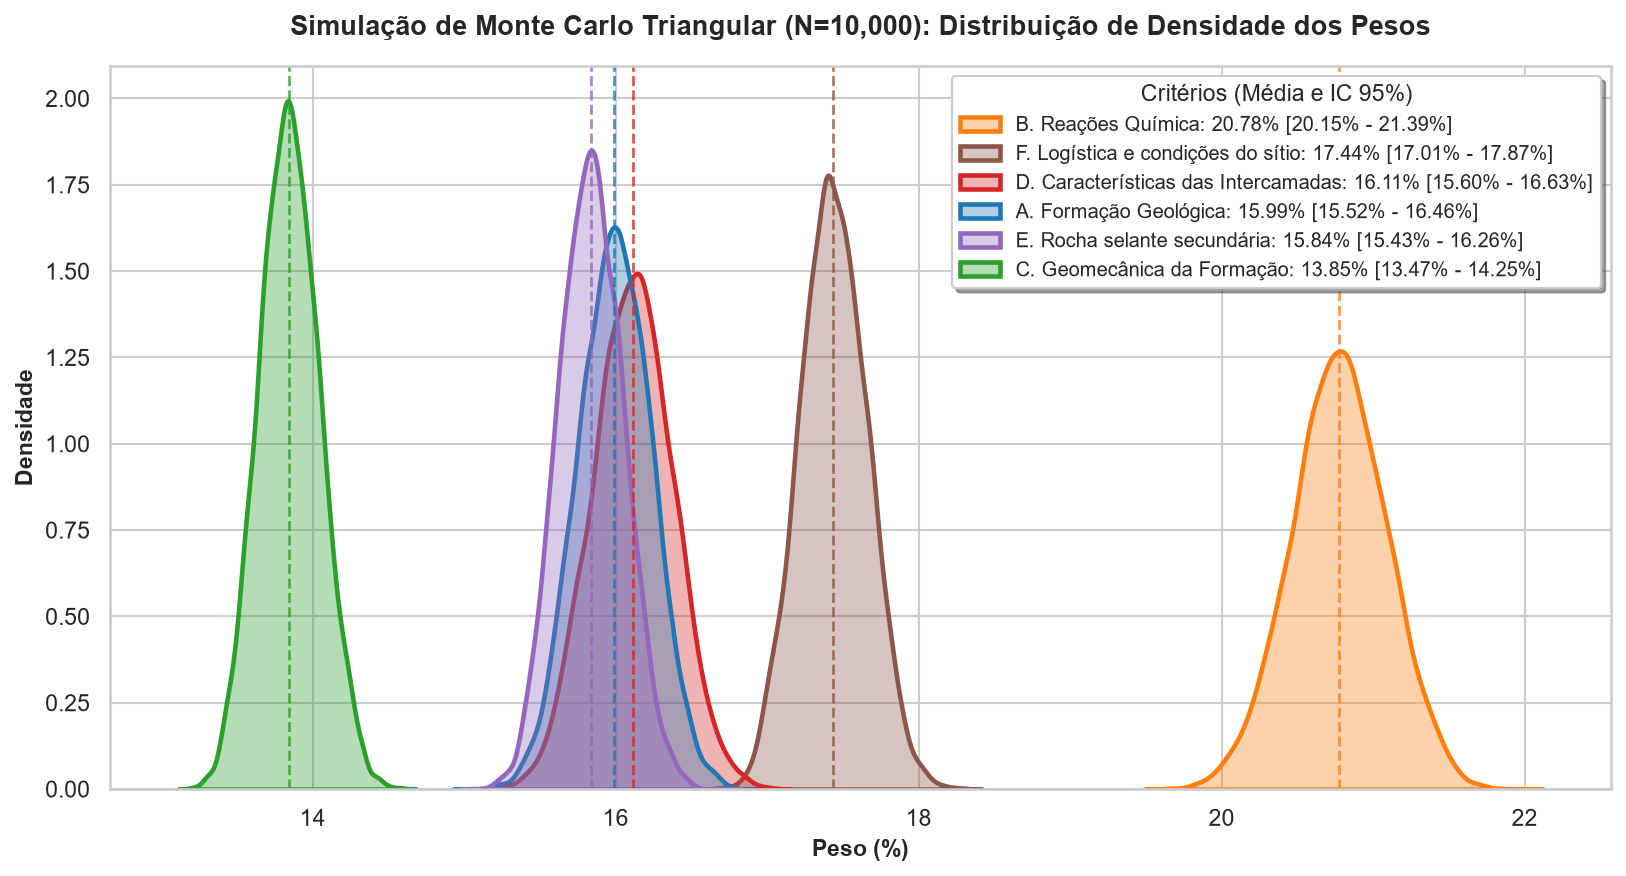

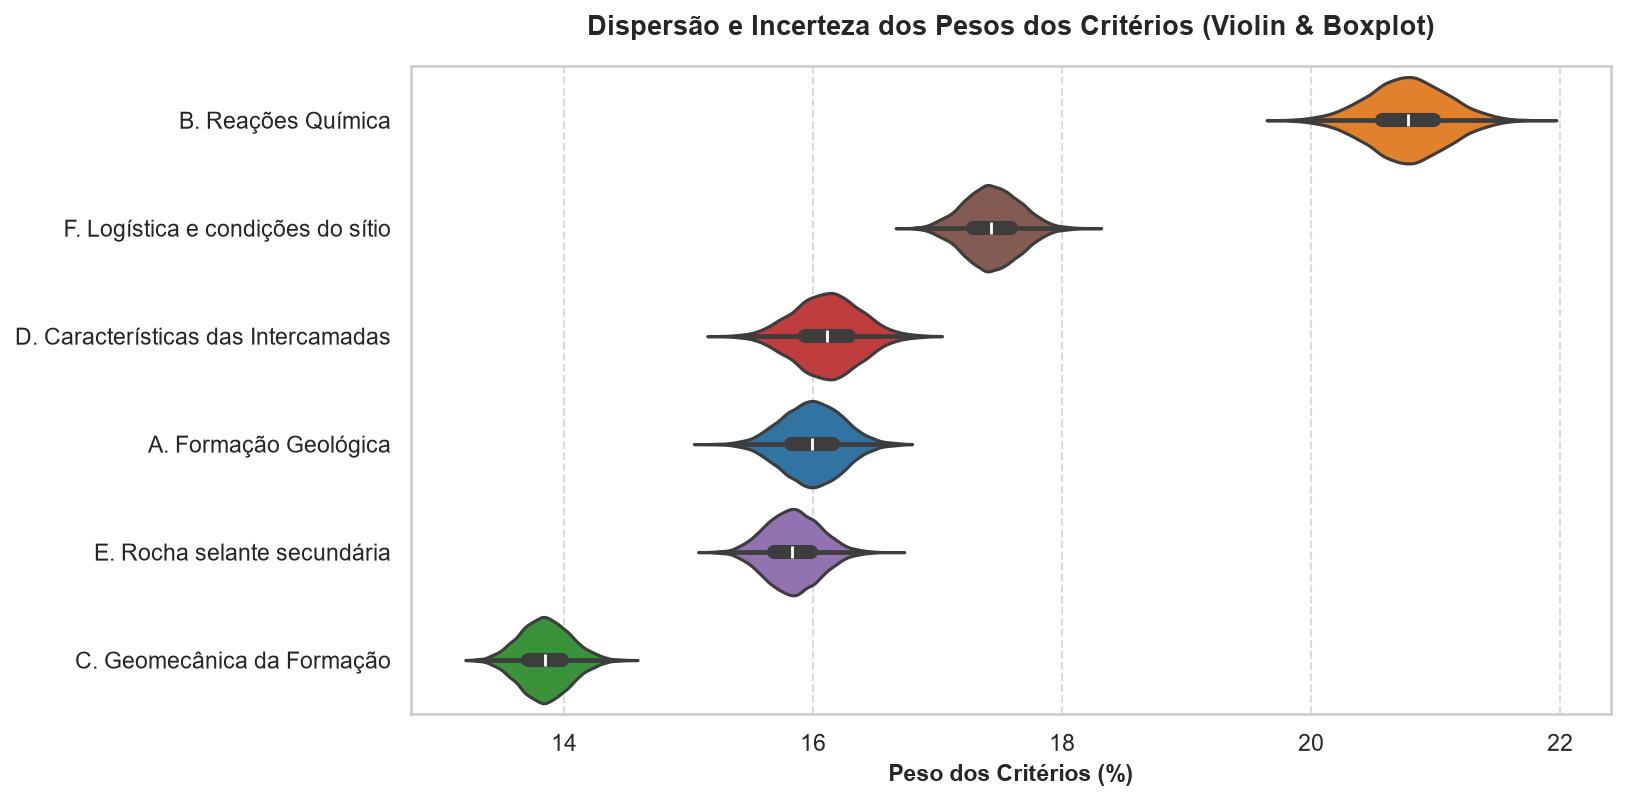

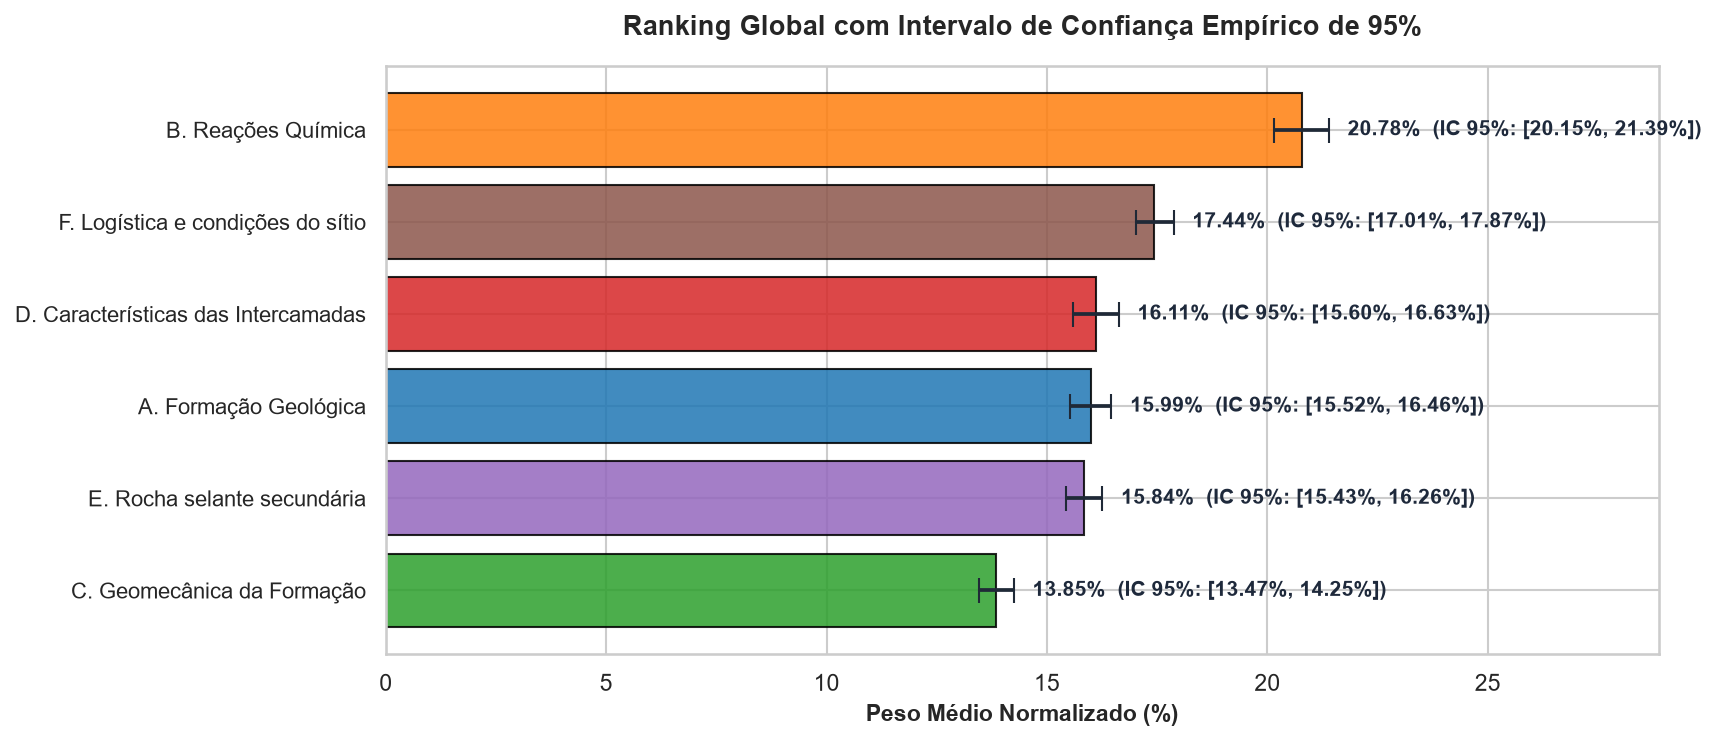

C:\Users\10091125\AppData\Local\Temp\ipykernel_2612\382573763.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


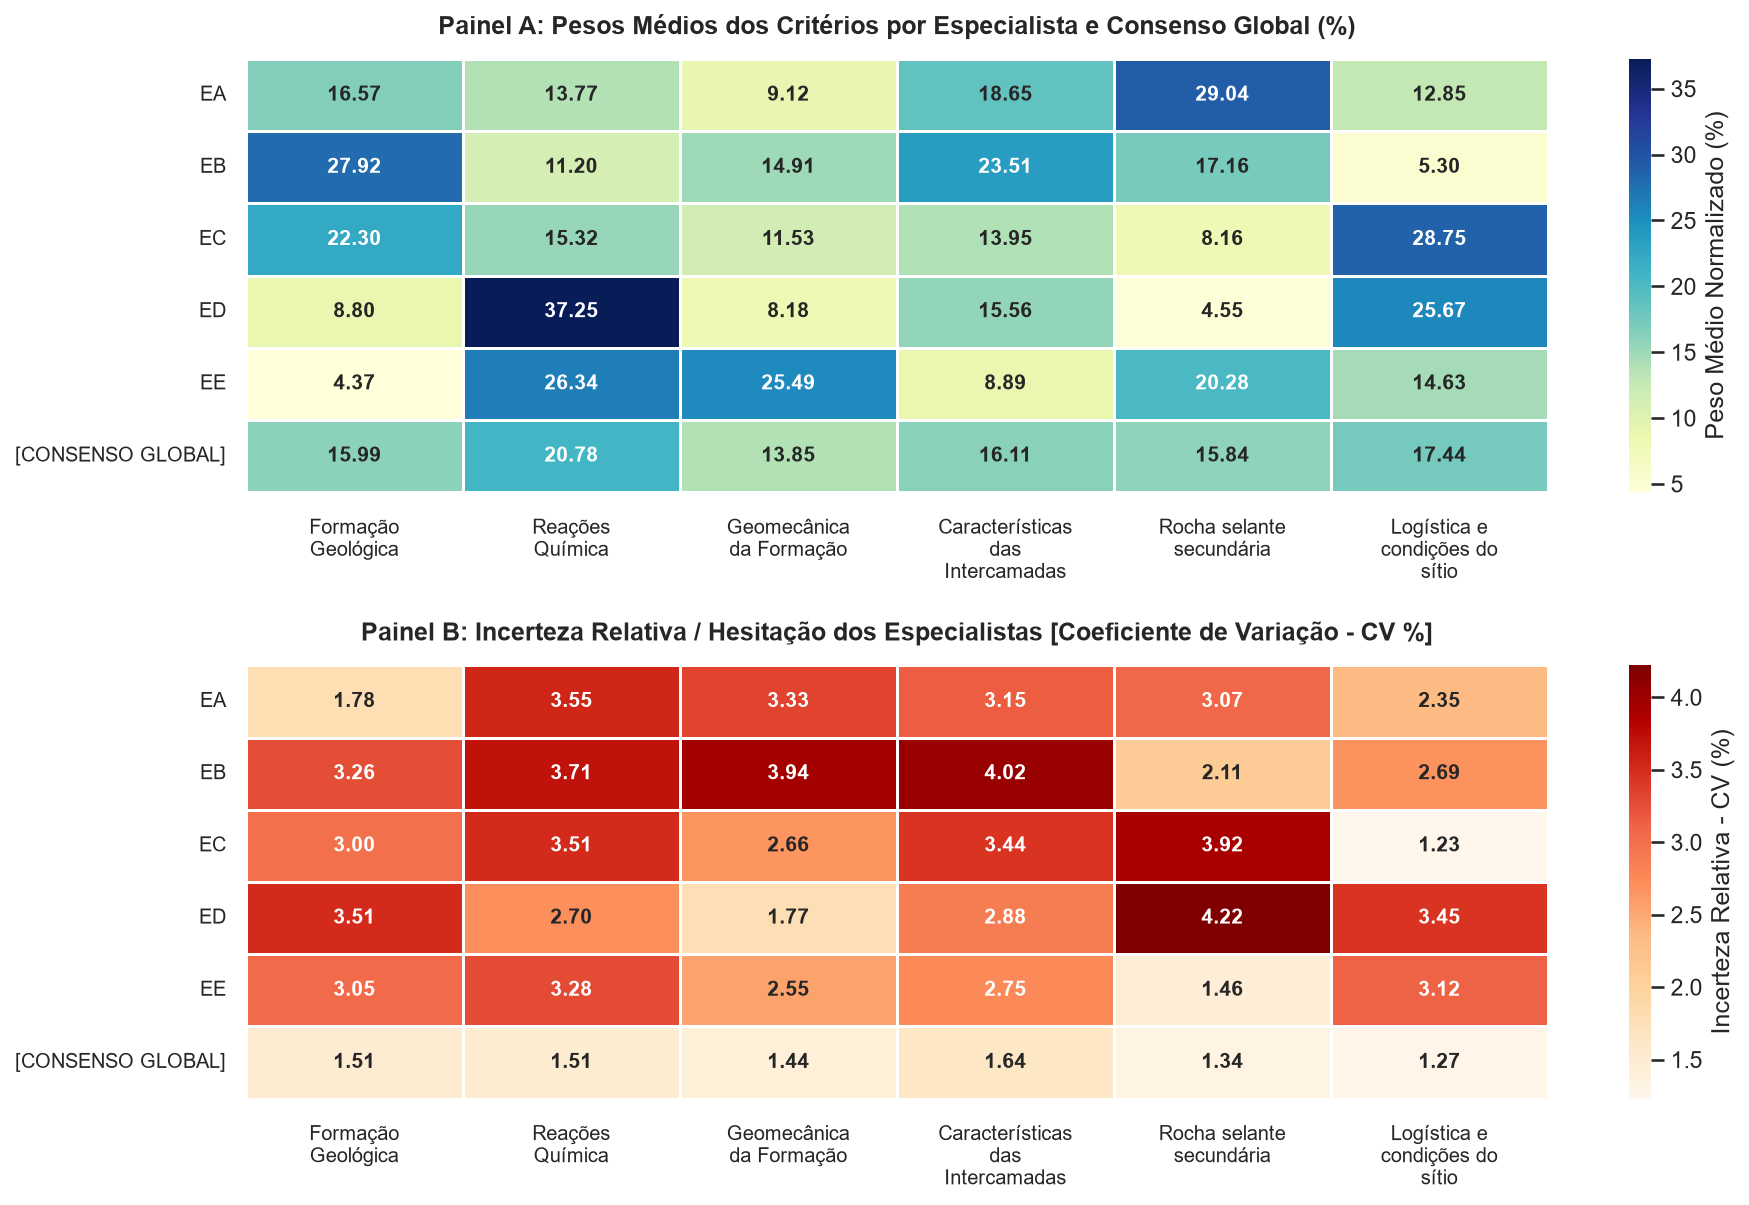

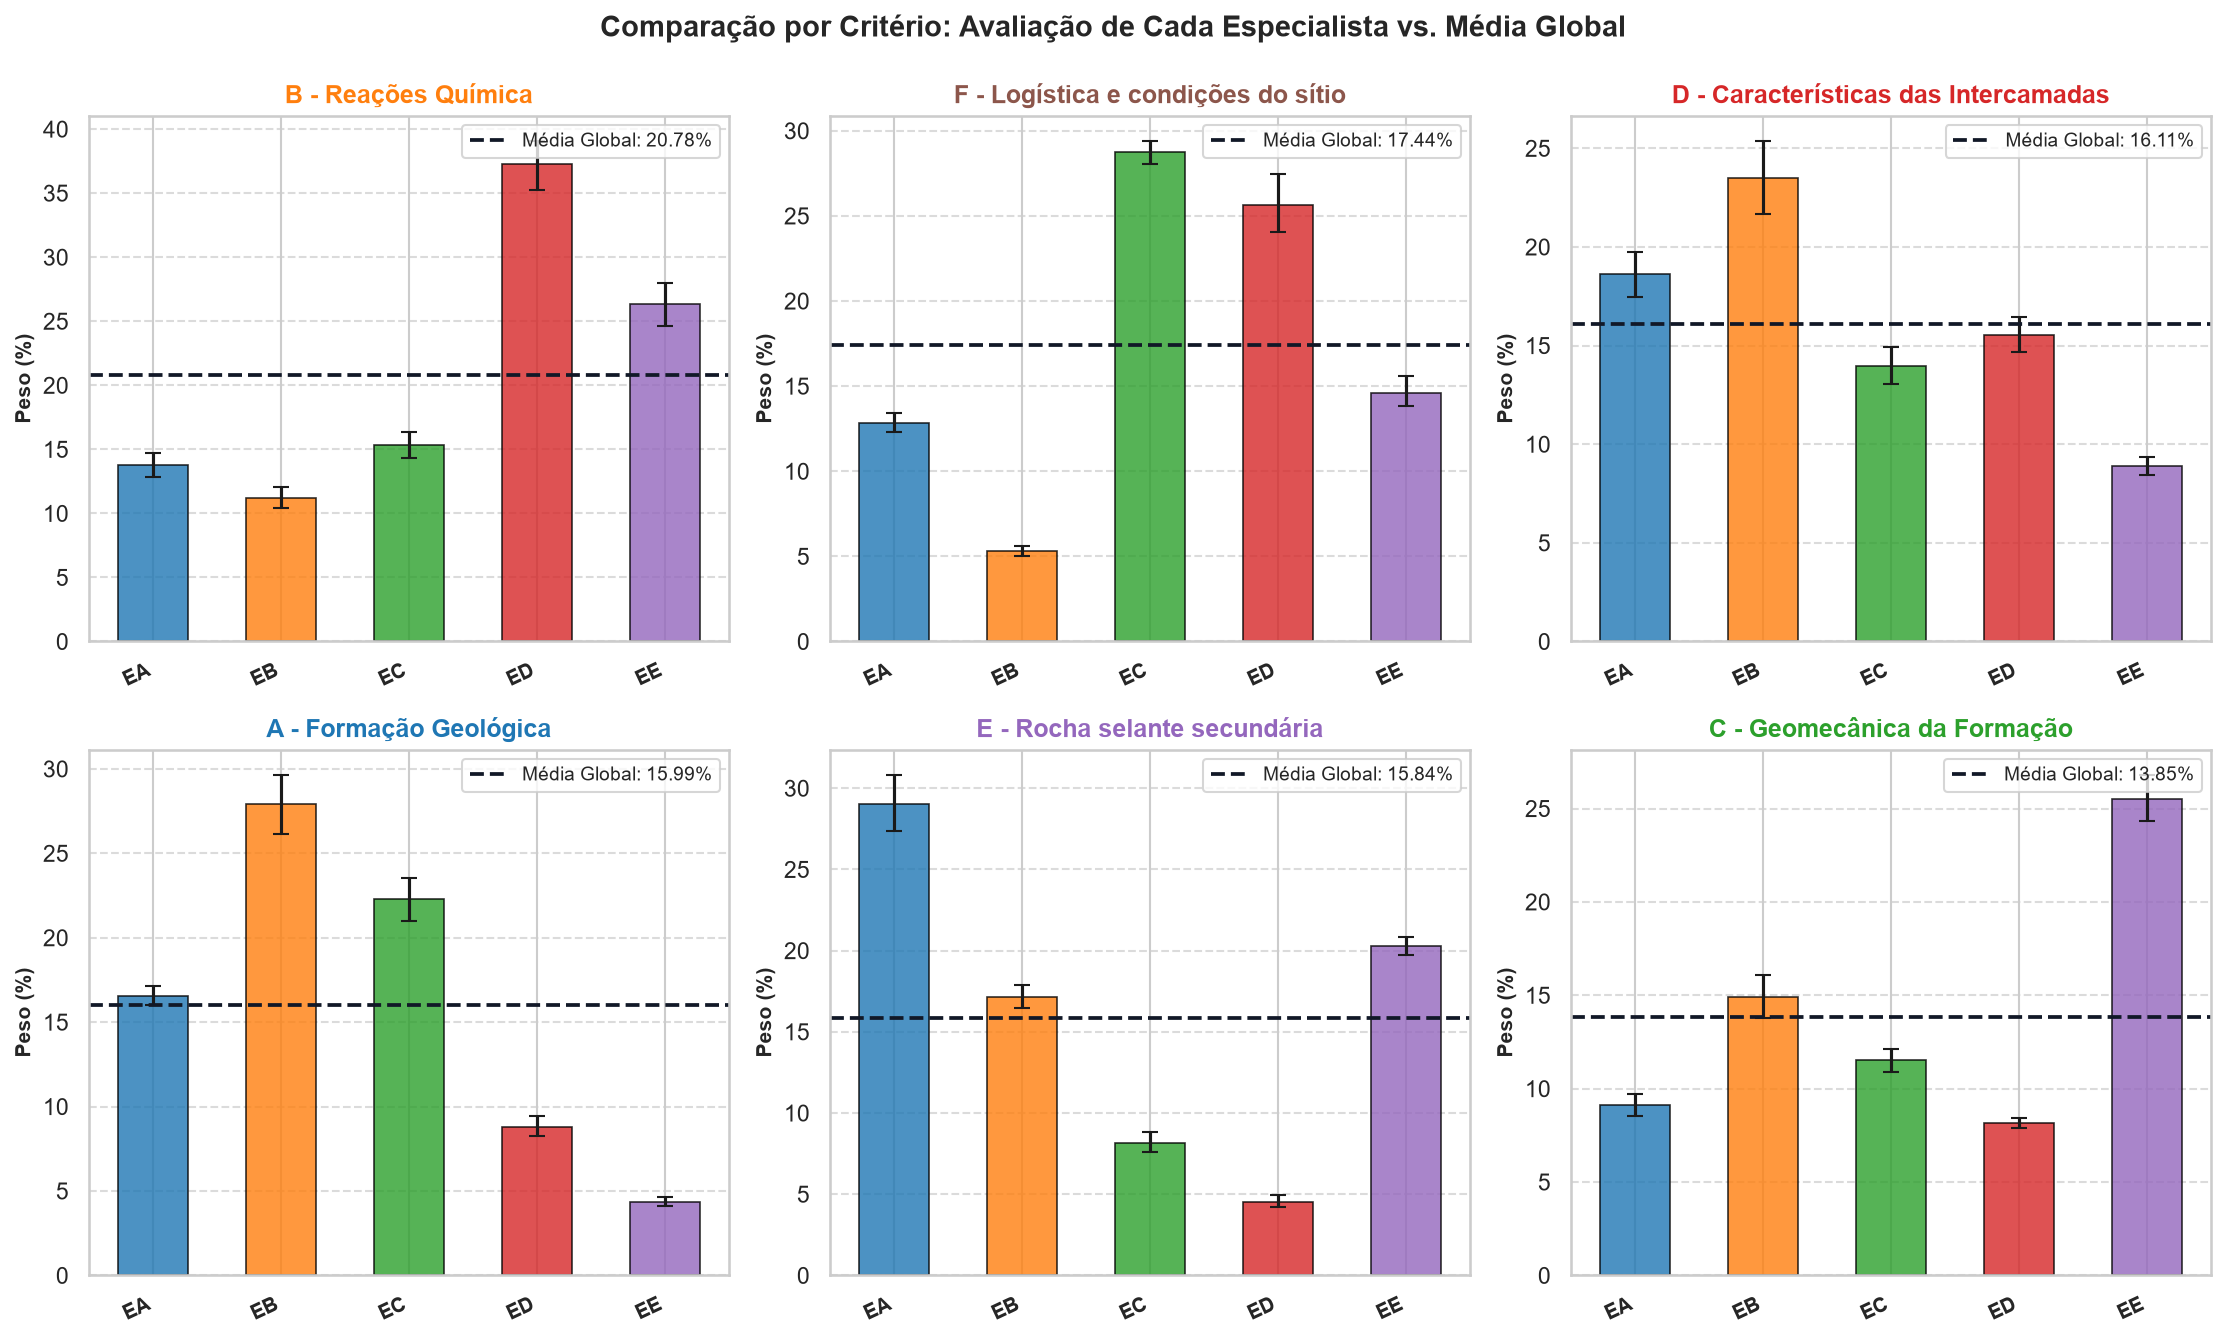

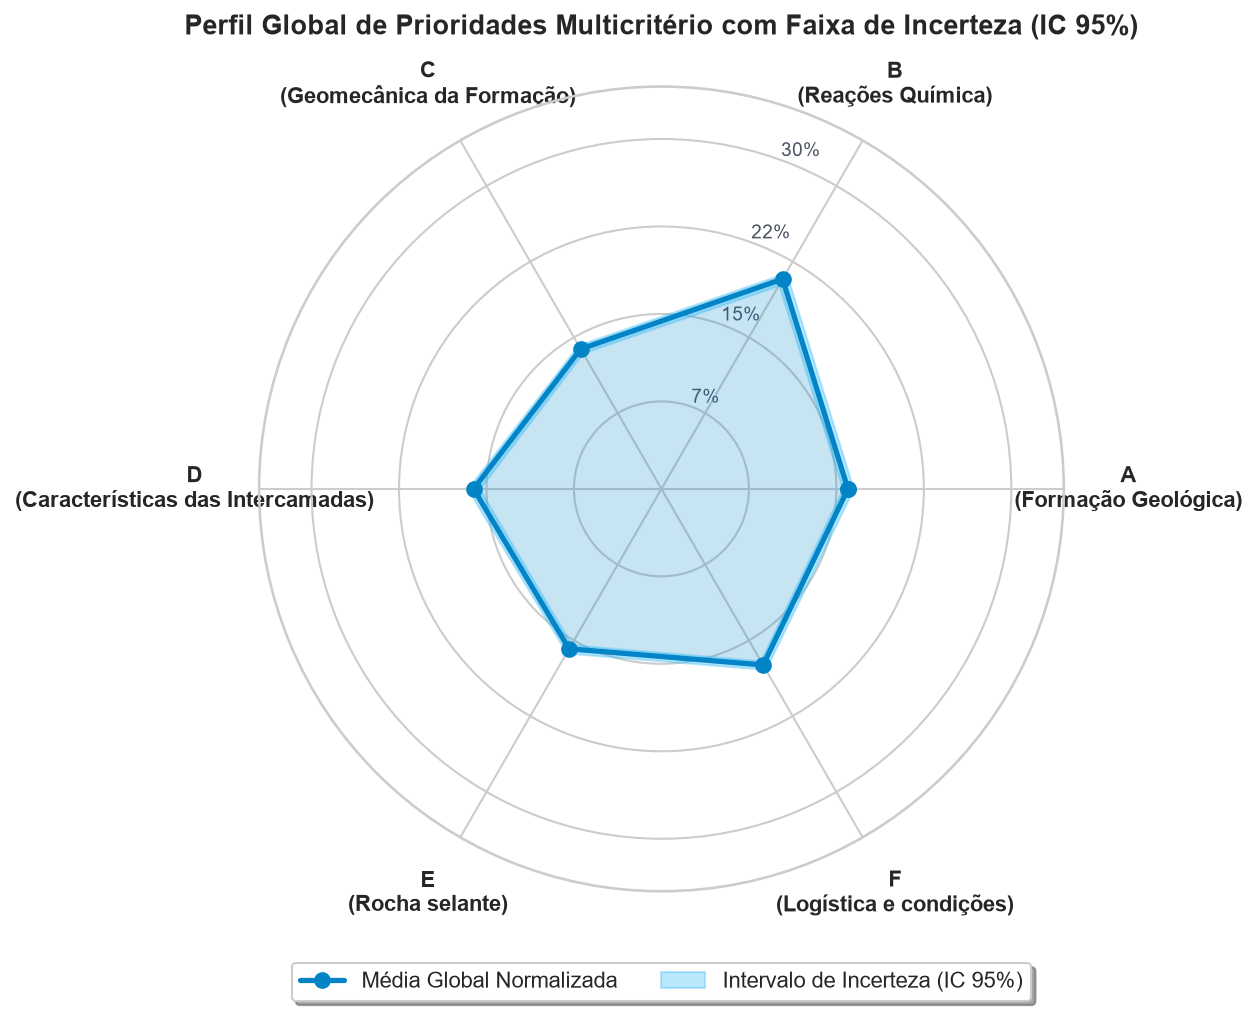


Todos os 6 gráficos dinâmicos e escaláveis foram gerados e salvos com sucesso!


In [16]:
# ETAPA 12: Visualização Gráfica Completa da Incerteza
if CONFIG_MC["EXPORTAR_FIGURAS"]:
    os.makedirs(str(CONFIG_MC["DIRETORIO_SAIDA"]), exist_ok=True)

# ==============================================================================
# GRÁFICO 1: Distribuição de Densidade dos Pesos (KDE)
# ==============================================================================
fig, ax = plt.subplots(figsize=(11, 6))
for crit in ordem_criterios:
    dados = np.asarray(df_sim_global[crit], dtype=float)
    cor = cores_criterios.get(crit, '#3b82f6')
    media = float(np.mean(dados))
    inf = float(np.percentile(dados, p_inf))
    sup = float(np.percentile(dados, p_sup))
    
    sns.kdeplot(x=dados, ax=ax, color=cor, fill=True, alpha=0.35, linewidth=2.2,
                label=f"{criterios_nomes.get(crit, crit)}: {media:.2f}% [{inf:.2f}% - {sup:.2f}%]")
    ax.axvline(media, color=cor, linestyle="--", linewidth=1.3, alpha=0.8)

ax.set_title(f"Simulação de Monte Carlo Triangular (N={n_sim:,}): Distribuição de Densidade dos Pesos", 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Peso (%)", fontsize=11, fontweight='bold')
ax.set_ylabel("Densidade", fontsize=11, fontweight='bold')
ax.legend(title=f"Critérios (Média e {ic_label})", title_fontsize='11', fontsize=9.5, loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
if CONFIG_MC["EXPORTAR_FIGURAS"]:
    plt.savefig(os.path.join(str(CONFIG_MC["DIRETORIO_SAIDA"]), "01_densidade_pesos_montecarlo.png"), dpi=int(CONFIG_MC["DPI"]), bbox_inches='tight')
plt.show()

# ==============================================================================
# GRÁFICO 2: Violin Plot com Boxplot Integrado
# ==============================================================================
fig, ax = plt.subplots(figsize=(11, max(5.5, n_crit * 0.9)))
df_melted = df_sim_global[ordem_criterios].melt(var_name="Critério", value_name="Peso (%)")
df_melted["Nome"] = df_melted["Critério"].map(lambda c: criterios_nomes.get(c, c))
nomes_ordenados = [criterios_nomes.get(c, c) for c in ordem_criterios]
palette_ordenada = [cores_criterios.get(c, '#3b82f6') for c in ordem_criterios]

sns.violinplot(
    data=df_melted, y="Nome", x="Peso (%)", hue="Nome", order=nomes_ordenados,
    palette=palette_ordenada, inner="box", cut=0, linewidth=1.5, legend=False, ax=ax
)
ax.set_title("Dispersão e Incerteza dos Pesos dos Critérios (Violin & Boxplot)", 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Peso dos Critérios (%)", fontsize=11, fontweight='bold')
ax.set_ylabel("")
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
if CONFIG_MC["EXPORTAR_FIGURAS"]:
    plt.savefig(os.path.join(str(CONFIG_MC["DIRETORIO_SAIDA"]), "02_violin_boxplot_incerteza.png"), dpi=int(CONFIG_MC["DPI"]), bbox_inches='tight')
plt.show()

# ==============================================================================
# GRÁFICO 3: Ranking com Barras de Incerteza (IC Dinâmico)
# ==============================================================================
fig, ax = plt.subplots(figsize=(11.5, max(5.0, n_crit * 0.85)))
medias = [float(np.mean(np.asarray(df_sim_global[c], dtype=float))) for c in ordem_criterios]
erros_inf = [float(np.mean(np.asarray(df_sim_global[c], dtype=float))) - float(np.percentile(np.asarray(df_sim_global[c], dtype=float), p_inf)) for c in ordem_criterios]
erros_sup = [float(np.percentile(np.asarray(df_sim_global[c], dtype=float), p_sup)) - float(np.mean(np.asarray(df_sim_global[c], dtype=float))) for c in ordem_criterios]
erros = np.array([erros_inf, erros_sup])
nomes_inv = [criterios_nomes.get(c, c) for c in ordem_criterios][::-1]
medias_inv = medias[::-1]
erros_inv = erros[:, ::-1]
cores_inv = [cores_criterios.get(c, '#3b82f6') for c in ordem_criterios][::-1]

y_pos = np.arange(len(nomes_inv))
bars = ax.barh(y_pos, medias_inv, xerr=erros_inv, color=cores_inv, alpha=0.85, 
               edgecolor='black', linewidth=1, capsize=6, error_kw={'elinewidth': 1.8, 'ecolor': '#1f2937'})

max_sup = max([m + e for m, e in zip(medias_inv, erros_inv[1])])
ax.set_xlim(0, max_sup * 1.35)

for i, (bar, m, e_i, e_s) in enumerate(zip(bars, medias_inv, erros_inv[0], erros_inv[1])):
    ax.text(m + e_s + (max_sup * 0.02), bar.get_y() + bar.get_height()/2, 
            f"{m:.2f}%  ({ic_label}: [{m - e_i:.2f}%, {m + e_s:.2f}%])", 
            va='center', ha='left', fontsize=10, fontweight='bold', color='#1e293b')

ax.set_yticks(y_pos)
ax.set_yticklabels(nomes_inv, fontsize=10.5)
ax.set_xlabel("Peso Médio Normalizado (%)", fontsize=11, fontweight='bold')
ax.set_title(f"Ranking Global com Intervalo de Confiança Empírico de {int(float(CONFIG_MC['NIVEL_CONF'])*100)}%", 
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
if CONFIG_MC["EXPORTAR_FIGURAS"]:
    plt.savefig(os.path.join(str(CONFIG_MC["DIRETORIO_SAIDA"]), "03_ranking_barras_ic95.png"), dpi=int(CONFIG_MC["DPI"]), bbox_inches='tight')
plt.show()

# ==============================================================================
# GRÁFICO 4: Heatmap Especialistas x Critérios (Pesos Médios & Incerteza Relativa CV%)
# ==============================================================================
esp_labels = [item["Name"] for item in fuzzy_data]

dados_pesos_esp = []
dados_cv_esp = []
for e_idx in range(n_esp):
    w_e = mc_pesos_especialistas[e_idx] * 100
    dados_pesos_esp.append([float(w_e[:, c_idx].mean()) for c_idx in range(n_crit)])
    dados_cv_esp.append([float((w_e[:, c_idx].std() / w_e[:, c_idx].mean()) * 100) for c_idx in range(n_crit)])

# Adiciona linha de consenso global
dados_pesos_esp.append([float(np.mean(np.asarray(df_sim_global[c], dtype=float))) for c in criterios])
dados_cv_esp.append([float((np.std(np.asarray(df_sim_global[c], dtype=float)) / np.mean(np.asarray(df_sim_global[c], dtype=float))) * 100) for c in criterios])

linhas_labels = esp_labels + ["[CONSENSO GLOBAL]"]

# Formata os nomes dos critérios com quebra de linha dinâmica (sem 'Critério A, B, C')
def rotulo_coluna_quebrado(crit: str, max_chars: int = 13) -> str:
    nome = criterios_nomes.get(crit, crit)
    limpo = re.sub(r"^(Crit[eé]rio\s*)?[A-Za-z0-9]+[\.\:\-\)]?\s*", "", nome, flags=re.IGNORECASE).strip()
    if not limpo:
        limpo = nome
    return textwrap.fill(limpo, width=max_chars, break_long_words=False)

colunas_labels = [rotulo_coluna_quebrado(c, max_chars=13) for c in criterios]

df_heat_pesos = pd.DataFrame(dados_pesos_esp, index=linhas_labels, columns=colunas_labels)
df_heat_cv = pd.DataFrame(dados_cv_esp, index=linhas_labels, columns=colunas_labels)

w_dinamica = max(14.0, n_crit * 2.3)
h_dinamica = max(9.0, n_esp * 0.5 + 4.5)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(w_dinamica, h_dinamica), gridspec_kw={'hspace': 0.40})

annot_tam = 10 if n_esp <= 10 else (8.5 if n_esp <= 25 else 7)
sns.heatmap(
    df_heat_pesos, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Peso Médio Normalizado (%)'},
    linewidths=1.2, linecolor='white', annot_kws={'fontsize': annot_tam, 'fontweight': 'bold'}, ax=ax1
)
ax1.set_title("Painel A: Pesos Médios dos Critérios por Especialista e Consenso Global (%)", 
              fontsize=12, fontweight='bold', pad=12)
ax1.tick_params(axis='y', rotation=0, labelsize=9.5)
ax1.tick_params(axis='x', rotation=0, labelsize=9.5, pad=6)

sns.heatmap(
    df_heat_cv, annot=True, fmt=".2f", cmap="OrRd", cbar_kws={'label': 'Incerteza Relativa - CV (%)'},
    linewidths=1.2, linecolor='white', annot_kws={'fontsize': annot_tam, 'fontweight': 'bold'}, ax=ax2
)
ax2.set_title("Painel B: Incerteza Relativa / Hesitação dos Especialistas [Coeficiente de Variação - CV %]", 
              fontsize=12, fontweight='bold', pad=12)
ax2.tick_params(axis='y', rotation=0, labelsize=9.5)
ax2.tick_params(axis='x', rotation=0, labelsize=9.5, pad=6)

plt.tight_layout()
if CONFIG_MC["EXPORTAR_FIGURAS"]:
    plt.savefig(os.path.join(str(CONFIG_MC["DIRETORIO_SAIDA"]), "04_heatmap_pesos_incerteza_especialistas.png"), dpi=int(CONFIG_MC["DPI"]), bbox_inches='tight')
plt.show()

# ==============================================================================
# GRÁFICO 5: Comparação dos Especialistas com Grid Dinâmico (ncols e nrows escaláveis)
# ==============================================================================
ncols = 3
nrows = math.ceil(n_crit / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows), sharey=False)
axes_flat = np.atleast_1d(axes).flatten()

usa_barras_individuais = (n_esp <= 12)
cores_paleta = sns.color_palette("tab10", n_esp)

for idx, crit in enumerate(ordem_criterios):
    ax = axes_flat[idx]
    c_idx = criterios.index(crit)
    cor_tema = cores_criterios.get(crit, '#3b82f6')
    media_glob = float(np.mean(np.asarray(df_sim_global[crit], dtype=float)))
    
    if usa_barras_individuais:
        medias_esp = [float(mc_pesos_especialistas[e_idx, :, c_idx].mean()) * 100 for e_idx in range(n_esp)]
        inf_esp = [float(np.percentile(mc_pesos_especialistas[e_idx, :, c_idx] * 100, p_inf)) for e_idx in range(n_esp)]
        sup_esp = [float(np.percentile(mc_pesos_especialistas[e_idx, :, c_idx] * 100, p_sup)) for e_idx in range(n_esp)]
        erros_y = [np.array(medias_esp) - np.array(inf_esp), np.array(sup_esp) - np.array(medias_esp)]
        
        x_pos = np.arange(n_esp)
        ax.bar(x_pos, medias_esp, yerr=erros_y, color=cores_paleta, alpha=0.8, 
               edgecolor='black', linewidth=0.8, capsize=4, width=0.55)
        ax.axhline(media_glob, color='#111827', linestyle='--', linewidth=1.8, 
                   label=f'Média Global: {media_glob:.2f}%')
        
        nomes_curtos_esp = [item["Name"] for item in fuzzy_data]
        ax.set_xticks(x_pos)
        ax.set_xticklabels(nomes_curtos_esp, fontsize=9.5, fontweight='bold', rotation=25, ha='right')
    else:
        pesos_esp_array = np.array([float(mc_pesos_especialistas[e_idx, :, c_idx].mean()) * 100 for e_idx in range(n_esp)])
        sns.boxplot(y=pesos_esp_array, ax=ax, color=cor_tema, width=0.4, boxprops=dict(alpha=0.6))
        sns.stripplot(y=pesos_esp_array, ax=ax, color='#111827', size=5, jitter=0.2, alpha=0.7)
        ax.axhline(media_glob, color='#dc2626', linestyle='--', linewidth=2, 
                   label=f'Média Global: {media_glob:.2f}%')
        ax.set_xlabel(f"Avaliadores (N={n_esp})", fontsize=10, fontweight='bold')
    
    ax.set_title(f"{crit} - {criterios_nomes.get(crit, crit).split('. ')[-1]}", 
                 fontsize=12, fontweight='bold', color=cor_tema)
    ax.set_ylabel("Peso (%)", fontsize=10, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

for ax_idx in range(n_crit, len(axes_flat)):
    fig.delaxes(axes_flat[ax_idx])

plt.suptitle("Comparação por Critério: Avaliação de Cada Especialista vs. Média Global", 
             fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
if CONFIG_MC["EXPORTAR_FIGURAS"]:
    plt.savefig(os.path.join(str(CONFIG_MC["DIRETORIO_SAIDA"]), "05_comparacao_especialistas_detalhada.png"), dpi=int(CONFIG_MC["DPI"]), bbox_inches='tight')
plt.show()

# ==============================================================================
# GRÁFICO 6: Radar / Spider Chart Dinâmico de Prioridades
# ==============================================================================
angles = np.linspace(0, 2 * np.pi, n_crit, endpoint=False).tolist()
angles += angles[:1]

medias_radar = [float(np.mean(np.asarray(df_sim_global[c], dtype=float))) for c in criterios] + [float(np.mean(np.asarray(df_sim_global[criterios[0]], dtype=float)))]
inf_radar = [float(np.percentile(np.asarray(df_sim_global[c], dtype=float), p_inf)) for c in criterios] + [float(np.percentile(np.asarray(df_sim_global[criterios[0]], dtype=float), p_inf))]
sup_radar = [float(np.percentile(np.asarray(df_sim_global[c], dtype=float), p_sup)) for c in criterios] + [float(np.percentile(np.asarray(df_sim_global[criterios[0]], dtype=float), p_sup))]

fig = plt.figure(figsize=(8.5, 8.5))
ax = fig.add_subplot(111, polar=True)

ax.plot(angles, medias_radar, 'o-', linewidth=2.5, color='#0284c7', label='Média Global Normalizada', markersize=7)
ax.fill(angles, medias_radar, alpha=0.22, color='#0284c7')
ax.fill_between(angles, inf_radar, sup_radar, color='#38bdf8', alpha=0.35, label=f'Intervalo de Incerteza ({ic_label})')

ax.set_xticks(angles[:-1])
labels_formatados = [f"{c}\n({criterios_curtos.get(c, c)})" for c in criterios]
ax.set_xticklabels(labels_formatados, fontsize=10.5, fontweight='bold')
ax.tick_params(axis='x', pad=18)

teto_radial = math.ceil(max(sup_radar) / 10.0) * 10
ax.set_ylim(0, teto_radial * 1.15)
ticks_radiais = np.linspace(0, teto_radial, 5)[1:]
ax.set_yticks(ticks_radiais)
ax.set_yticklabels([f"{int(t)}%" for t in ticks_radiais], fontsize=9, color='#4b5563')
getattr(ax, "set_rlabel_position")(70)

ax.set_title(f"Perfil Global de Prioridades Multicritério com Faixa de Incerteza ({ic_label})", 
             fontsize=13, fontweight='bold', pad=25)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=10.5, frameon=True, shadow=True)

plt.tight_layout()
if CONFIG_MC["EXPORTAR_FIGURAS"]:
    plt.savefig(os.path.join(str(CONFIG_MC["DIRETORIO_SAIDA"]), "06_radar_pesos_incerteza.png"), dpi=int(CONFIG_MC["DPI"]), bbox_inches='tight')
plt.show()

print("\nTodos os 6 gráficos dinâmicos e escaláveis foram gerados e salvos com sucesso!")